In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


In [2]:

movies = pd.read_csv("C:/Users/KIIT0001/Desktop/AI-Retention-System/data/movies.csv")

ratings = pd.read_csv("C:/Users/KIIT0001/Desktop/AI-Retention-System/data/ratings.csv")

print(movies.shape)
print(ratings.shape)


(87585, 3)
(32000204, 4)


In [3]:
# extract year
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')

# convert to int
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')

# drop null years
movies = movies.dropna(subset=['year'])

# convert to int
movies['year'] = movies['year'].astype(int)

print("After year extraction:", movies.shape)


After year extraction: (86970, 4)


In [4]:
movies = movies[movies['year'] >= 2000]

print("After year filter:", movies.shape)


After year filter: (51447, 4)


In [5]:
movies = movies[movies['genres'] != '(no genres listed)']

print("After genre cleaning:", movies.shape)


After genre cleaning: (48127, 4)


In [6]:
movie_counts = ratings['movieId'].value_counts()

popular_movies = movie_counts[movie_counts >= 80].index

ratings = ratings[ratings['movieId'].isin(popular_movies)]
movies = movies[movies['movieId'].isin(popular_movies)]

print("After popularity filter:")
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)


After popularity filter:
Movies: (7035, 4)
Ratings: (31324750, 4)


In [7]:
user_counts = ratings['userId'].value_counts()

active_users = user_counts[user_counts >= 50].index

ratings = ratings[ratings['userId'].isin(active_users)]

print("After active user filter:", ratings.shape)


After active user filter: (29022747, 4)


In [8]:
movie_std = ratings.groupby('movieId')['rating'].std()

good_movies = movie_std[movie_std > 0.5].index

ratings = ratings[ratings['movieId'].isin(good_movies)]
movies = movies[movies['movieId'].isin(good_movies)]

print("After variance filter:")
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)


After variance filter:
Movies: (7035, 4)
Ratings: (29022747, 4)


In [9]:
top_movies = ratings['movieId'].value_counts().head(7000).index

ratings = ratings[ratings['movieId'].isin(top_movies)]
movies = movies[movies['movieId'].isin(top_movies)]

print("Final dataset:")
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)


Final dataset:
Movies: (3509, 4)
Ratings: (27901403, 4)


In [10]:
user_movie_matrix = ratings.pivot_table(
    index='movieId',
    columns='userId',
    values='rating'
).fillna(0)

print(user_movie_matrix.shape)


(7000, 127958)


In [11]:
from scipy.sparse import csr_matrix

sparse_matrix = csr_matrix(user_movie_matrix.values)

print("Sparse matrix ready")


Sparse matrix ready


In [12]:
from sklearn.neighbors import NearestNeighbors

model = NearestNeighbors(metric='cosine', algorithm='brute')

model.fit(sparse_matrix)

print("Model trained successfully 🚀")


Model trained successfully 🚀


In [17]:
# mapping (VERY IMPORTANT)
movie_ids = user_movie_matrix.index.tolist()

joblib.dump(model, "movie_model.pkl", compress=3)
joblib.dump(movie_ids, "movie_ids.pkl", compress=3)
joblib.dump(movies, "movies.pkl", compress=3)

print("Saved optimized files ✅")


Saved optimized files ✅


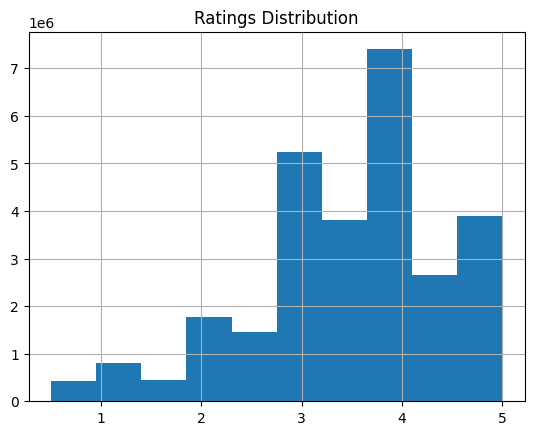

In [18]:
import matplotlib.pyplot as plt

# ratings distribution
ratings['rating'].hist(bins=10)
plt.title("Ratings Distribution")
plt.show()
